Loading sensitivity area results...
Results loaded successfully!

Found 4 models:
  - Euclid Run 1
  - Euclid Run 2
  - Interf. Run 1
  - Interf. Run 2

Creating percentage sensitivity curves plot...
Figure saved as 'percentage_sensitivity_curves.png'

Plot created successfully!

Sample percentage sensitive areas:
--------------------------------------------------

Euclid Run 1:
  At 10^9 M_sun: 0.24%
  At 10^10 M_sun: 7.57%

Euclid Run 2:
  At 10^9 M_sun: 0.40%
  At 10^10 M_sun: 8.52%

Interf. Run 1:
  At 10^9 M_sun: 0.01%
  At 10^10 M_sun: 0.59%

Interf. Run 2:
  At 10^9 M_sun: 0.00%
  At 10^10 M_sun: 0.25%


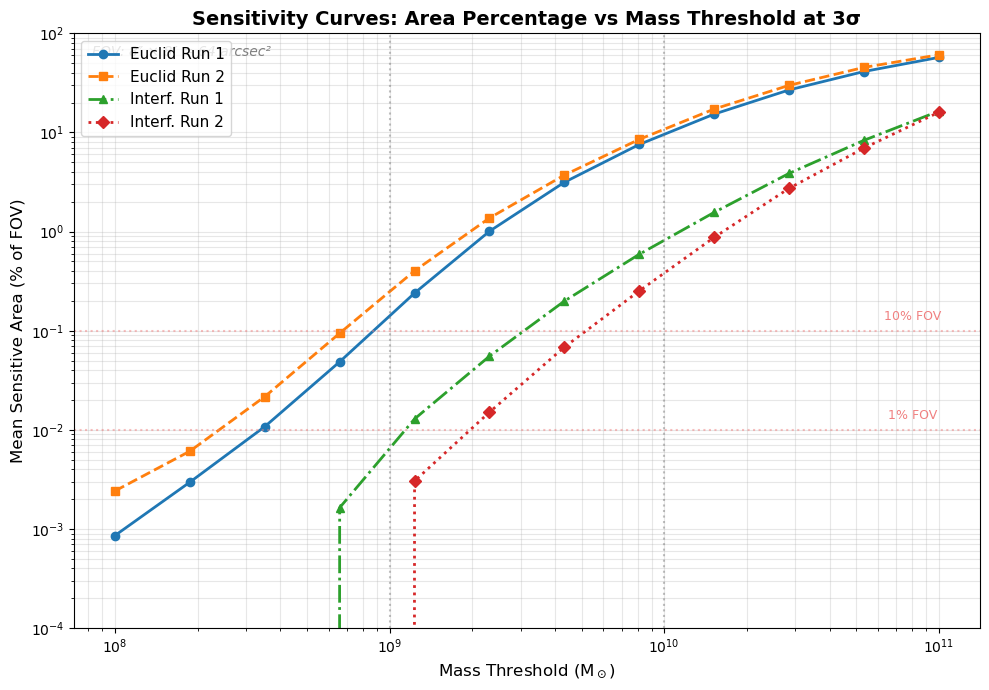

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fractional_sensitivity_curves(results, save_figure=True):
    """
    Plot sensitivity curves showing mean fractional sensitive area vs mass threshold.
    
    Args:
        results: Dictionary containing sensitivity analysis results
        save_figure: Whether to save the figure
    
    Returns:
        matplotlib figure
    """
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Total FOV area: 8 arcsec × 8 arcsec = 64 arcsec²
    total_fov_area = 64.0
    
    # Define line styles for different models
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Plot for each model
    for idx, (model_name, model_results) in enumerate(results.items()):
        mass_thresholds = model_results['mass_thresholds']
        mean_areas = model_results['mean_areas']
        
        # Convert to percentage area
        percentage_areas = (mean_areas / total_fov_area) * 100
        
        # Plot percentage area
        ax.plot(mass_thresholds, percentage_areas, 
               label=model_name,
               linestyle=line_styles[idx % len(line_styles)],
               marker=markers[idx % len(markers)],
               color=colors[idx % len(colors)],
               linewidth=2,
               markersize=6,
               markevery=1)
    
    # Formatting
    ax.set_xlabel('Mass Threshold (M$_\\odot$)', fontsize=12)
    ax.set_ylabel('Mean Sensitive Area (% of FOV)', fontsize=12)
    ax.set_title('Sensitivity Curves: Area Percentage vs Mass Threshold at 3σ', 
                fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper left', fontsize=11)
    
    # Set y-axis limits to show percentages properly
    ax.set_ylim(0.0001, 100)
    
    # Add reference lines
    ax.axvline(1e9, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(1e10, color='gray', linestyle=':', alpha=0.5)
    
    # Add horizontal reference lines for fractional areas
    ax.axhline(0.1, color='lightcoral', linestyle=':', alpha=0.5)
    ax.axhline(0.01, color='lightcoral', linestyle=':', alpha=0.5)
    

    
    # Add text labels for fractional reference lines
    ax.text(1e11*0.8, 0.1*1.2, '10% FOV', 
            ha='center', va='bottom', color='lightcoral', fontsize=9)
    ax.text(1e11*0.8, 0.01*1.2, '1% FOV', 
            ha='center', va='bottom', color='lightcoral', fontsize=9)
    
    # Add subtitle with FOV info
    ax.text(0.02, 0.98, f'FOV: 8″ × 8″ = 64 arcsec²', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', style='italic', color='gray')
    
    plt.tight_layout()
    
    if save_figure:
        fig.savefig('percentage_sensitivity_curves.png', dpi=150, bbox_inches='tight')
        print("Figure saved as 'percentage_sensitivity_curves.png'")
    
    return fig


# Main execution
if __name__ == "__main__":
    print("Loading sensitivity area results...")
    
    # Load the saved results
    try:
        results = np.load('sensitivity_maps/sensitivity_area_results.npy', allow_pickle=True).item()
        print("Results loaded successfully!")
        
        # Print available models
        print(f"\nFound {len(results)} models:")
        for model_name in results.keys():
            print(f"  - {model_name}")
        
        print("\nCreating percentage sensitivity curves plot...")
        
        # Create the plot
        fig = plot_fractional_sensitivity_curves(results, save_figure=True)
        
        print("\nPlot created successfully!")
        
        # Print some sample percentage areas
        total_fov_area = 64.0
        print("\nSample percentage sensitive areas:")
        print("-" * 50)
        
        for model_name, model_results in results.items():
            mass_thresholds = model_results['mass_thresholds']
            mean_areas = model_results['mean_areas']
            percentage_areas = (mean_areas / total_fov_area) * 100
            
            # Find indices for specific masses
            idx_1e9 = np.argmin(np.abs(mass_thresholds - 1e9))
            idx_1e10 = np.argmin(np.abs(mass_thresholds - 1e10))
            
            print(f"\n{model_name}:")
            print(f"  At 10^9 M_sun: {percentage_areas[idx_1e9]:.2f}%")
            print(f"  At 10^10 M_sun: {percentage_areas[idx_1e10]:.2f}%")
        
        # Optionally show the plot
        plt.show()
        
    except FileNotFoundError:
        print("Error: 'sensitivity_area_results.npy' not found!")
        print("Make sure you have run the analysis script first to generate the data.")
    except Exception as e:
        print(f"Error loading data: {e}")